# Taller B5-T1 · Generación de datos financieros sintéticos
## Notebook 02 — Arquitectura downstream y baselines no generativos

**Objetivo.** Antes de generar un solo dato sintético, este notebook fija dos cosas que el
resto del taller tratará como constantes:

1. **El suelo del experimento**: tres baselines clásicos sin redes (media global,
   persistencia de la volatilidad realizada, HAR-RV lineal). Cualquier red — y cualquier
   mezcla real+sintético — tendrá que justificarse frente a ellos.
2. **La arquitectura downstream congelada**: el enunciado exige buscar una arquitectura
   válida con datos reales y reutilizarla *idéntica* en todas las mezclas real/sintético.
   Aquí se hace esa búsqueda, se elige campeona por validación (real), se cuantifica su
   ruido de optimización con varias semillas y se persiste su configuración y sus pesos.

**Regla de congelación.** A partir de este notebook, ni la arquitectura ni los
hiperparámetros de entrenamiento cambian: si una celda de la malla real×sintético rinde
distinto, la única explicación posible serán los datos. Ese es el diseño experimental.

> Módulos: `src/baselines.py` (predictores clásicos y métricas), `src/models.py`
> (arquitecturas candidatas), `src/training.py` (harness único de entrenamiento con
> early stopping sobre validación real).

## 0 · Setup y contrato de datos

Consumimos exclusivamente los artefactos del notebook 01. La estandarización usa los
estadísticos congelados de train (`standardizer.json`); el test no interviene en ninguna
decisión de este notebook — solo se informa al final, como referencia.

In [1]:
import sys, json, time
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.config import Config, set_global_seed
from src.baselines import predict_global_mean, predict_persistence, HarOLS, regression_metrics
from src.models import build_model, count_params
from src.training import train_model, predict, get_device
from src.eda import PALETTE, _style

cfg = Config()
set_global_seed(cfg.seed)
device = get_device()
if device.type == "cpu":
    torch.set_num_threads(8)
print("Device:", device)

d = np.load(cfg.out_dir / "windows_dataset.npz")
std = json.load(open(cfg.out_dir / "standardizer.json"))
X = {s: d[f"X_{s}"] for s in ("train", "val", "test")}
y = {s: d[f"y_{s}"] for s in ("train", "val", "test")}

# Versiones estandarizadas (entrada de las redes). Los baselines usan X crudo:
# calculan volatilidades realizadas en unidades físicas.
Xs = {s: (X[s] - std["x_mu"]) / std["x_sd"] for s in X}
ys = {s: (y[s] - std["y_mu"]) / std["y_sd"] for s in y}
{s: X[s].shape for s in X}

Device: cuda


{'train': (88619, 60), 'val': (14527, 60), 'test': (19864, 60)}

## 1 · Protocolo de evaluación

* **Métricas**: MSE, MAE y R² en el espacio del target, `y = ln σ_anualizada`. El R² se
  calcula contra la varianza del target *dentro de cada partición* — con distribution
  shift entre particiones (documentado en el 01) es la única comparación honesta.
* **Selección**: todas las decisiones (arquitectura, época de la que se conservan los
  pesos) se toman con **validación real**. El test se informa una única vez por modelo, como referencia, y no
  alimenta ninguna decisión.
* **Ruido de optimización**: la campeona se reentrena con 3 semillas; la dispersión entre
  semillas es la vara de medir para saber si una diferencia futura entre mezclas
  real/sintético es señal o ruido.

## 2 · Baselines no generativos

| Baseline | Qué explota | Por qué está aquí |
|---|---|---|
| Media global de train | nada (constante) | detecta el shift de nivel entre particiones |
| Persistencia RV-21 | la persistencia de σ | el heurístico del practicante: "la vol que viene será como la que hubo" |
| HAR-RV (OLS) | RV a 1/5/21/60 días | el estándar de la literatura (Corsi, 2009); lineal y sin hiperparámetros |

In [2]:
har = HarOLS().fit(X["train"], y["train"])

baseline_preds = {
    "media_global": {s: predict_global_mean(y["train"], len(y[s])) for s in ("val", "test")},
    "persistencia_rv21": {s: predict_persistence(X[s]) for s in ("val", "test")},
    "har_ols": {s: har.predict(X[s]) for s in ("val", "test")},
}

rows = []
for name, preds in baseline_preds.items():
    for s in ("val", "test"):
        rows.append({"modelo": name, "particion": s, **regression_metrics(y[s], preds[s])})
tabla_baselines = pd.DataFrame(rows).set_index(["modelo", "particion"]).round(4)
print("Coeficientes HAR [const, lnRV1, lnRV5, lnRV21, lnRV60]:", np.round(har.coef_, 3))
tabla_baselines

Coeficientes HAR [const, lnRV1, lnRV5, lnRV21, lnRV60]: [-0.381  0.003  0.13   0.1    0.497]


mse     mae      r2
modelo            particion                        
media_global      val        0.1955  0.3457 -0.1645
                  test       0.2466  0.3811 -0.1431
persistencia_rv21 val        0.1461  0.2948  0.1300
                  test       0.1961  0.3421  0.0910
har_ols           val        0.0985  0.2416  0.4134
                  test       0.1364  0.2825  0.3679

**Lectura crítica.** Tres observaciones que condicionan todo lo que sigue:

1. **La media global tiene R² negativo en val y test.** No es un error: es el
   distribution shift del notebook 01 haciéndose visible — la media de train (anclada en
   la calma 2012–2019) queda sistemáticamente por debajo del nivel de σ de 2022–2026.
   Cualquier modelo que aprenda *algo* de la ventana lo supera de largo.
2. **La persistencia ya captura una parte de la señal** con cero parámetros: la
   persistencia de σ es real y explotable.
3. **HAR-RV es el listón serio** (R² ≈ 0,36 en test con 5 coeficientes). La distancia
   entre HAR y la mejor red medirá cuánta no-linealidad adicional hay que extraer de la
   ventana; la experiencia de la literatura es que esa distancia es real pero modesta.
   Si una red no bate a HAR, la red sobra — y lo mismo valdrá para los datos sintéticos.

## 3 · Búsqueda de arquitectura (con datos reales)

Cuatro candidatas pequeñas, dos familias (MLP y CNN 1-D), de ~15k a ~120k parámetros.
Pequeñas a propósito: el objeto del taller es medir el efecto de los *datos*, y la malla
posterior requiere cientos de entrenamientos — un modelo grande añadiría varianza de
optimización y coste sin cambiar la pregunta. Mismo harness, mismos hiperparámetros de
entrenamiento, misma semilla: la comparación es entre arquitecturas, no entre recetas.

> **Receta de entrenamiento — dos elementos que no son cosméticos.** El target
> estandarizado tiene colas de hasta |z| ≈ 7,7 y las entradas hasta |z| ≈ 30. Con MSE, un
> lote que contenga una de esas muestras aporta una pérdida ~50 frente a la típica ~0,4:
> un pico de gradiente de dos órdenes de magnitud. Sin tratarlo, las curvas de validación
> salen con dientes de sierra y **no demuestran convergencia** — justo lo que el enunciado
> exige demostrar. La solución correcta es **recortar la norma del gradiente**
> (`grad_clip=1.0`), que acota el tamaño del paso sin tocar el objetivo; winsorizar el
> target lo habría "arreglado" cambiando el problema, inadmisible en un taller cuyo objeto
> son precisamente las colas. Añadimos además **cosine annealing** del learning rate y
> entrenamos el horizonte completo (sin parada temprana, `patience = epochs`), quedándonos
> con los mejores pesos: así la última parte de cada curva refina en lugar de rebotar y la
> convergencia es inequívoca a simple vista.

> **Política de épocas — búsqueda corta, finalistas largas.** Comparar 5 arquitecturas a
> 300 épocas sería pagar 5 veces el coste para descartar 3: la ordenación entre candidatas
> se estabiliza mucho antes que su convergencia fina. Hacemos una **búsqueda a 60 épocas**
> para ordenar, y reentrenamos solo las **dos finalistas a 300 épocas** (horizonte completo,
> cosine annealing hasta el final): ahí es donde exigimos ver las curvas de loss
> completamente aplanadas, y de ahí sale la campeona que se congela.


In [3]:
# Cinco candidatas, tres familias: densa (mlp), convolucional plana (cnn),
# convolucional con BatchNorm+Dropout (cnn_bn), convolucional dilatada (tcn)
# y recurrente (gru). Ver src/models.py para la motivación de cada una.
CANDIDATAS = {
    "mlp_l":  ("mlp",    {"hidden": (256, 128, 64)}),
    "cnn_l":  ("cnn",    {"channels": (32, 64, 128), "fc": 128}),
    "cnn_bn": ("cnn_bn", {}),   # (32,64,128,128) + BN + dropout 0.2, ~159k params
    "tcn":    ("tcn",    {}),   # dilataciones (1,2,4,8) + residual, ~92k params
    "gru":    ("gru",    {}),   # 2 capas GRU h=64, ~42k params
}
EPOCHS_BUSQUEDA = 60
TRAIN_KW = dict(epochs=EPOCHS_BUSQUEDA, batch_size=1024, lr=1e-3, weight_decay=1e-5,
                patience=EPOCHS_BUSQUEDA, grad_clip=1.0, cosine=True)

resultados = {}
for name, (arch, kw) in CANDIDATAS.items():
    model = build_model(arch, **kw)
    res = train_model(model, Xs["train"], ys["train"], Xs["val"], ys["val"],
                      seed=cfg.seed, device=device, **TRAIN_KW)
    # métricas en el espacio físico ln σ (des-estandarizando la predicción)
    pv = predict(model, Xs["val"], device) * std["y_sd"] + std["y_mu"]
    resultados[name] = {"model": model, "res": res,
                        "val": regression_metrics(y["val"], pv),
                        "params": count_params(model)}
    print(f"{name:6s} | {resultados[name]['params']:>7,} params | "
          f"mejor época {res.best_epoch:3d} | val MSE {resultados[name]['val']['mse']:.4f} | "
          f"{res.seconds:.0f}s")


mlp_l  |  56,833 params | mejor época   5 | val MSE 0.1015 | 9s


cnn_l  |  68,225 params | mejor época   4 | val MSE 0.0915 | 17s


cnn_bn | 159,169 params | mejor época   7 | val MSE 0.0894 | 27s


tcn    |  92,097 params | mejor época   2 | val MSE 0.0889 | 91s


gru    |  42,049 params | mejor época  28 | val MSE 0.0873 | 49s


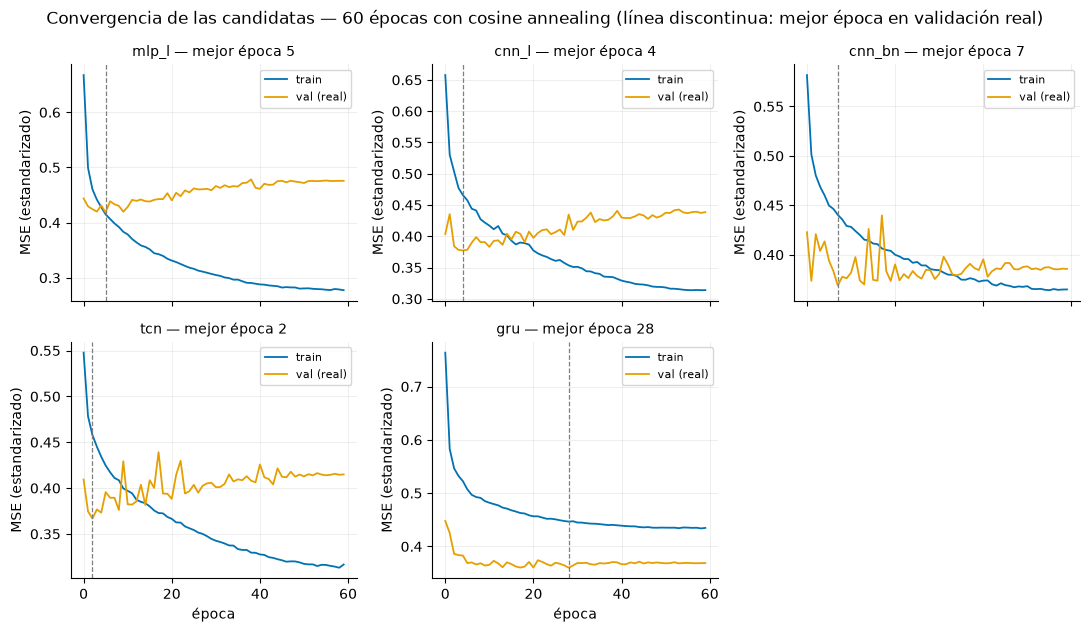

In [4]:
# Curvas de loss: el requisito de convergencia del enunciado, para cada candidata
n_cand = len(resultados)
n_cols = 3
n_rows = int(np.ceil(n_cand / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(11, 3.2 * n_rows), sharex=True)
axes = np.atleast_2d(axes)
for ax, (name, r) in zip(axes.ravel(), resultados.items()):
    h = r["res"]
    ax.plot(h.train_loss, color=PALETTE["blue"], lw=1.3, label="train")
    ax.plot(h.val_loss, color=PALETTE["orange"], lw=1.3, label="val (real)")
    ax.axvline(h.best_epoch, color=PALETTE["grey"], ls="--", lw=0.9)
    ax.set_title(f"{name} — mejor época {h.best_epoch}", fontsize=10)
    ax.set_ylabel("MSE (estandarizado)")
    ax.legend(fontsize=8)
    _style(ax)
for ax in axes.ravel()[n_cand:]:        # ejes sobrantes de la rejilla, fuera
    ax.set_visible(False)
for ax in axes[-1]:
    ax.set_xlabel("época")
fig.suptitle(f"Convergencia de las candidatas — {EPOCHS_BUSQUEDA} épocas con cosine annealing "
             "(línea discontinua: mejor época en validación real)")
fig.tight_layout()
fig.savefig(cfg.fig_dir / "09_convergencia_candidatas.png", dpi=120, bbox_inches="tight")


**Prueba numérica de convergencia.** "Se ve plana" no es un criterio. Medimos, sobre las
**últimas 10 épocas** de cada curva de validación, el cociente máximo/mínimo (cercano a 1
= meseta) y la pendiente de una recta ajustada (cercana a 0 = sin tendencia residual, ni
de mejora ni de degradación). Es la evidencia que respalda la afirmación de convergencia
que exige el enunciado.

In [5]:
conv = []
for name, r in resultados.items():
    v = np.array(r["res"].val_loss)[-10:]
    conv.append({"modelo": name,
                 "val_max/min_ult10": v.max() / v.min(),
                 "pendiente_ult10": np.polyfit(np.arange(len(v)), v, 1)[0],
                 "val_final": v[-1]})
pd.DataFrame(conv).set_index("modelo").round(4)

,val_max/min_ult10,pendiente_ult10,val_final
modelo,,,
mlp_l,1.0096,0.0002,0.4757
cnn_l,1.0131,-0.0001,0.4385
cnn_bn,1.0094,-0.0001,0.3857
tcn,1.0086,0.0001,0.4149
gru,1.0057,-0.0000,0.3687


### 3.b Finalistas a 300 épocas

Las dos mejores candidatas por MSE de validación se reentrenan con **300 épocas** —
5 veces el horizonte de búsqueda. Aquí es donde el requisito de convergencia del
enunciado se demuestra de verdad: con cosine annealing el learning rate muere en cero
al final del horizonte, así que si la curva de validación sigue moviéndose en las
últimas décadas de épocas, no era convergencia. La campeona sale de esta fase, nunca
de la búsqueda corta.


Finalistas (por val MSE en la búsqueda): ['gru', 'tcn']



gru    | mejor época  13/300 | val MSE 0.0873 (búsqueda: 0.0873) | 244s


tcn    | mejor época   2/300 | val MSE 0.0892 (búsqueda: 0.0889) | 507s


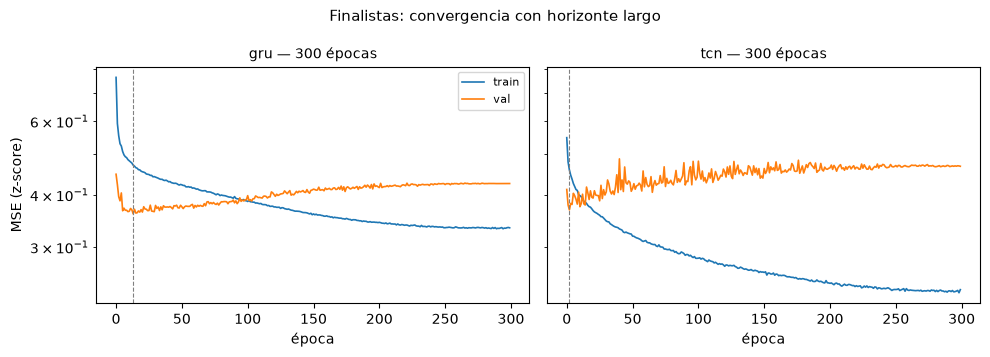


max/min de la loss de validación en las últimas 10 épocas: {'gru': np.float64(1.0003), 'tcn': np.float64(1.0051)}


In [6]:
EPOCHS_LARGO = 300
TRAIN_KW_LARGO = dict(epochs=EPOCHS_LARGO, batch_size=1024, lr=1e-3, weight_decay=1e-5,
                      patience=EPOCHS_LARGO, grad_clip=1.0, cosine=True)

orden = sorted(resultados, key=lambda k: resultados[k]["val"]["mse"])
FINALISTAS = orden[:2]
print(f"Finalistas (por val MSE en la búsqueda): {FINALISTAS}\n")

finalistas = {}
for name in FINALISTAS:
    arch, kw = CANDIDATAS[name]
    model = build_model(arch, **kw)
    res = train_model(model, Xs["train"], ys["train"], Xs["val"], ys["val"],
                      seed=cfg.seed, device=device, **TRAIN_KW_LARGO)
    pv = predict(model, Xs["val"], device) * std["y_sd"] + std["y_mu"]
    finalistas[name] = {"model": model, "res": res,
                        "val": regression_metrics(y["val"], pv)}
    print(f"{name:6s} | mejor época {res.best_epoch:3d}/{EPOCHS_LARGO} | "
          f"val MSE {finalistas[name]['val']['mse']:.4f} "
          f"(búsqueda: {resultados[name]['val']['mse']:.4f}) | {res.seconds:.0f}s")

# Curvas de loss de las finalistas: la prueba de convergencia con horizonte largo
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
for ax, name in zip(axes, FINALISTAS):
    r = finalistas[name]["res"]
    ax.plot(r.train_loss, label="train", lw=1.2)
    ax.plot(r.val_loss, label="val", lw=1.2)
    ax.axvline(r.best_epoch, color="grey", lw=0.8, ls="--")
    ax.set_title(f"{name} — {EPOCHS_LARGO} épocas", fontsize=10)
    ax.set_xlabel("época"); ax.set_yscale("log")
axes[0].set_ylabel("MSE (z-score)"); axes[0].legend(fontsize=8)
fig.suptitle("Finalistas: convergencia con horizonte largo", fontsize=11)
fig.tight_layout()
fig.savefig(cfg.fig_dir / "16_convergencia_finalistas.png", dpi=120, bbox_inches="tight")
plt.show()

v10 = {n: (np.array(f["res"].val_loss)[-10:].max() /
           np.array(f["res"].val_loss)[-10:].min()) for n, f in finalistas.items()}
print("\nmax/min de la loss de validación en las últimas 10 épocas:",
      {k: round(v, 4) for k, v in v10.items()})


## 4 · Selección, las tres semillas y congelación

**Por qué reentrenar la campeona con tres semillas.** Entrenar una red no es un cálculo
determinista: la inicialización de los pesos, el orden en que se barajan los lotes y las
máscaras de dropout dependen de un generador de números pseudoaleatorios, y la *semilla*
es el número que lo fija. Reentrenar con las semillas 42, 43 y 44 es repetir el
experimento tres veces cambiando **solo ese azar** — misma arquitectura, mismos datos,
mismos hiperparámetros. Nos da dos cosas:

1. **Un test de robustez.** Si los tres R² de test salen casi idénticos, el resultado es
   una propiedad del modelo y de los datos; si bailaran varios puntos, la "campeona"
   habría sido lotería de inicialización y la comparación de arquitecturas no sería fiable.
2. **La barra de error de todo lo que sigue.** La desviación entre semillas define el
   ruido de optimización del pipeline. En el notebook 04, una mejora por datos sintéticos
   solo cuenta si supera esa dispersión — sin las tres semillas no habría umbral honesto.

De las tres ejecuciones se congela (pesos incluidos) la de la semilla **mediana** en
validación: ni la más afortunada ni la menos, la representativa.


In [7]:
champion_name = min(finalistas, key=lambda k: finalistas[k]["val"]["mse"])
arch, kw = CANDIDATAS[champion_name]
print(f"Campeona por validación (fase larga): {champion_name}  ({arch}, {kw})")

runs = []
for seed in (42, 43, 44):
    m = build_model(arch, **kw)
    r = train_model(m, Xs["train"], ys["train"], Xs["val"], ys["val"],
                    seed=seed, device=device, **TRAIN_KW_LARGO)
    met = {}
    for s in ("val", "test"):
        p = predict(m, Xs[s], device) * std["y_sd"] + std["y_mu"]
        met[s] = regression_metrics(y[s], p)
    runs.append({"seed": seed, "model": m, "epoca": r.best_epoch, **{
        f"{s}_{k}": v for s in met for k, v in met[s].items()}})

tabla_seeds = pd.DataFrame(runs).drop(columns="model").set_index("seed").round(4)
resumen = tabla_seeds.agg(["mean", "std"]).round(4)
display(tabla_seeds); display(resumen)


Campeona por validación (fase larga): gru  (gru, {})


,epoca,val_mse,val_mae,val_r2,test_mse,test_mae,test_r2
seed,,,,,,,
42,13,0.0873,0.2273,0.4800,0.1239,0.2655,0.4256
43,15,0.0873,0.2280,0.4803,0.1258,0.2693,0.4171
44,24,0.0875,0.2288,0.4788,0.1235,0.2676,0.4276


,epoca,val_mse,val_mae,val_r2,test_mse,test_mae,test_r2
mean,17.3333,0.0874,0.2280,0.4797,0.1244,0.2675,0.4234
std,5.8595,0.0001,0.0008,0.0008,0.0012,0.0019,0.0056


In [8]:
# Persistencia del modelo de referencia: config + pesos de la semilla mediana en val
med_seed_idx = int(np.argsort([r["val_mse"] for r in runs])[len(runs) // 2])
champion_model = runs[med_seed_idx]["model"]

ref = {
    "arch": arch, "arch_kwargs": kw, "train_kwargs": TRAIN_KW_LARGO,
    "champion": champion_name, "seed_guardada": int(runs[med_seed_idx]["seed"]),
    "metricas_seeds": {str(r["seed"]): {c: float(r[c]) for c in
        ("val_mse", "val_mae", "val_r2", "test_mse", "test_mae", "test_r2")} for r in runs},
    "baselines_test": {n: {k: float(v) for k, v in
        regression_metrics(y["test"], p["test"]).items()} for n, p in baseline_preds.items()},
}
with open(cfg.out_dir / "downstream_reference.json", "w") as f:
    json.dump(ref, f, indent=2)
torch.save(champion_model.state_dict(), cfg.out_dir / "downstream_reference.pt")
print("Congelado:", champion_name, "->", cfg.out_dir / "downstream_reference.{json,pt}")

Congelado: gru -> C:\dev\MIAX_Tareas\taller_b5t1\data\processed\downstream_reference.{json,pt}


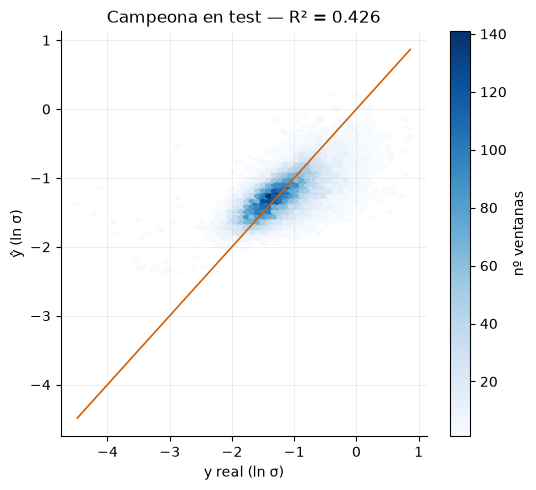

In [9]:
# Diagnóstico visual de la campeona en test: predicción vs realidad
p_test = predict(champion_model, Xs["test"], device) * std["y_sd"] + std["y_mu"]
fig, ax = plt.subplots(figsize=(5.5, 5))
hb = ax.hexbin(y["test"], p_test, gridsize=60, cmap="Blues", mincnt=1)
lims = [min(y["test"].min(), p_test.min()), max(y["test"].max(), p_test.max())]
ax.plot(lims, lims, color=PALETTE["vermillion"], lw=1.2)
ax.set_xlabel("y real (ln σ)"), ax.set_ylabel("ŷ (ln σ)")
ax.set_title(f"Campeona en test — R² = {regression_metrics(y['test'], p_test)['r2']:.3f}")
fig.colorbar(hb, ax=ax, label="nº ventanas")
_style(ax)
fig.tight_layout()
fig.savefig(cfg.fig_dir / "10_pred_vs_real.png", dpi=120, bbox_inches="tight")

## 5 · Análisis crítico y contrato para los notebooks siguientes

**Lo que queda fijado** (nada de esto se vuelve a tocar):

* Arquitectura campeona + hiperparámetros de entrenamiento → `downstream_reference.json`
  (la malla la reconstruirá con `build_model(ref["arch"], **ref["arch_kwargs"])`).
* Métricas de referencia con 3 semillas: la dispersión entre semillas define el umbral de
  relevancia para cualquier efecto de los datos sintéticos.
* El suelo: HAR-RV. En la malla, cada mezcla real+sintético se comparará contra la red
  entrenada solo con reales *y* contra HAR con los mismos reales.

**Lo que este notebook enseña, en frío:**

1. La ventaja de la mejor red sobre HAR existe pero es acotada — coherente con la
   literatura de RV forecasting. Esa distancia acota también el techo de lo que los datos
   sintéticos pueden aportar en el régimen de datos abundantes: poco. **La hipótesis del
   taller es que su valor aparecerá en el régimen de escasez** (pocas ventanas reales),
   que es exactamente lo que barrerá la malla del notebook 04.
2. La regresión hacia la media es visible en el hexbin: el modelo comprime los extremos
   (sobreestima σ baja, subestima σ alta). Típico de MSE + colas; relevante porque los
   generadores que no reproduzcan colas tenderán a agravarlo.
3. El tiempo por entrenamiento medido aquí dimensiona la malla del 04: con la campeona
   congelada, cientos de entrenamientos son viables en la RTX 5070 (y asumibles en CPU).

**Siguiente notebook (03):** los generadores — baselines simples (jitter, gaussiana
multivariante, block bootstrap) y las tres familias neuronales (CVAE, WGAN-GP, flow),
entrenados exclusivamente con las ventanas reales de train y auditados contra los hechos
estilizados del notebook 01.